<a href="https://colab.research.google.com/github/NahomKidane/ai301-labs/blob/main/m03-embeddings/guided-labs/AI301_Guided_Lab_Part1_Library_From_Token_Ids_to_Vectors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 301 Guided Lab: Embeddings, Part 1 · From Token Ids to Vectors

**Module 3 · Embeddings**

> **File > Save a copy in Drive** before you start.

Module 2 ended with a list of integers and the claim that each one is a row in a matrix the model
learned. This notebook runs that claim. You put ids in, get vectors out, and then find the same word
carrying two different vectors in two different sentences.

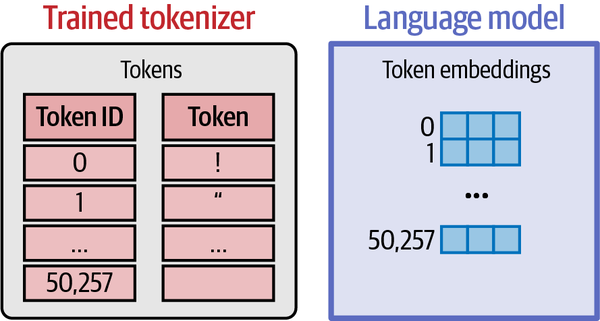

Figure 2-7 from Alammar and Grootendorst, *Hands On Large Language Models*, chapter 2. The
tokenizer owns the vocabulary. The model owns one vector per entry in it.

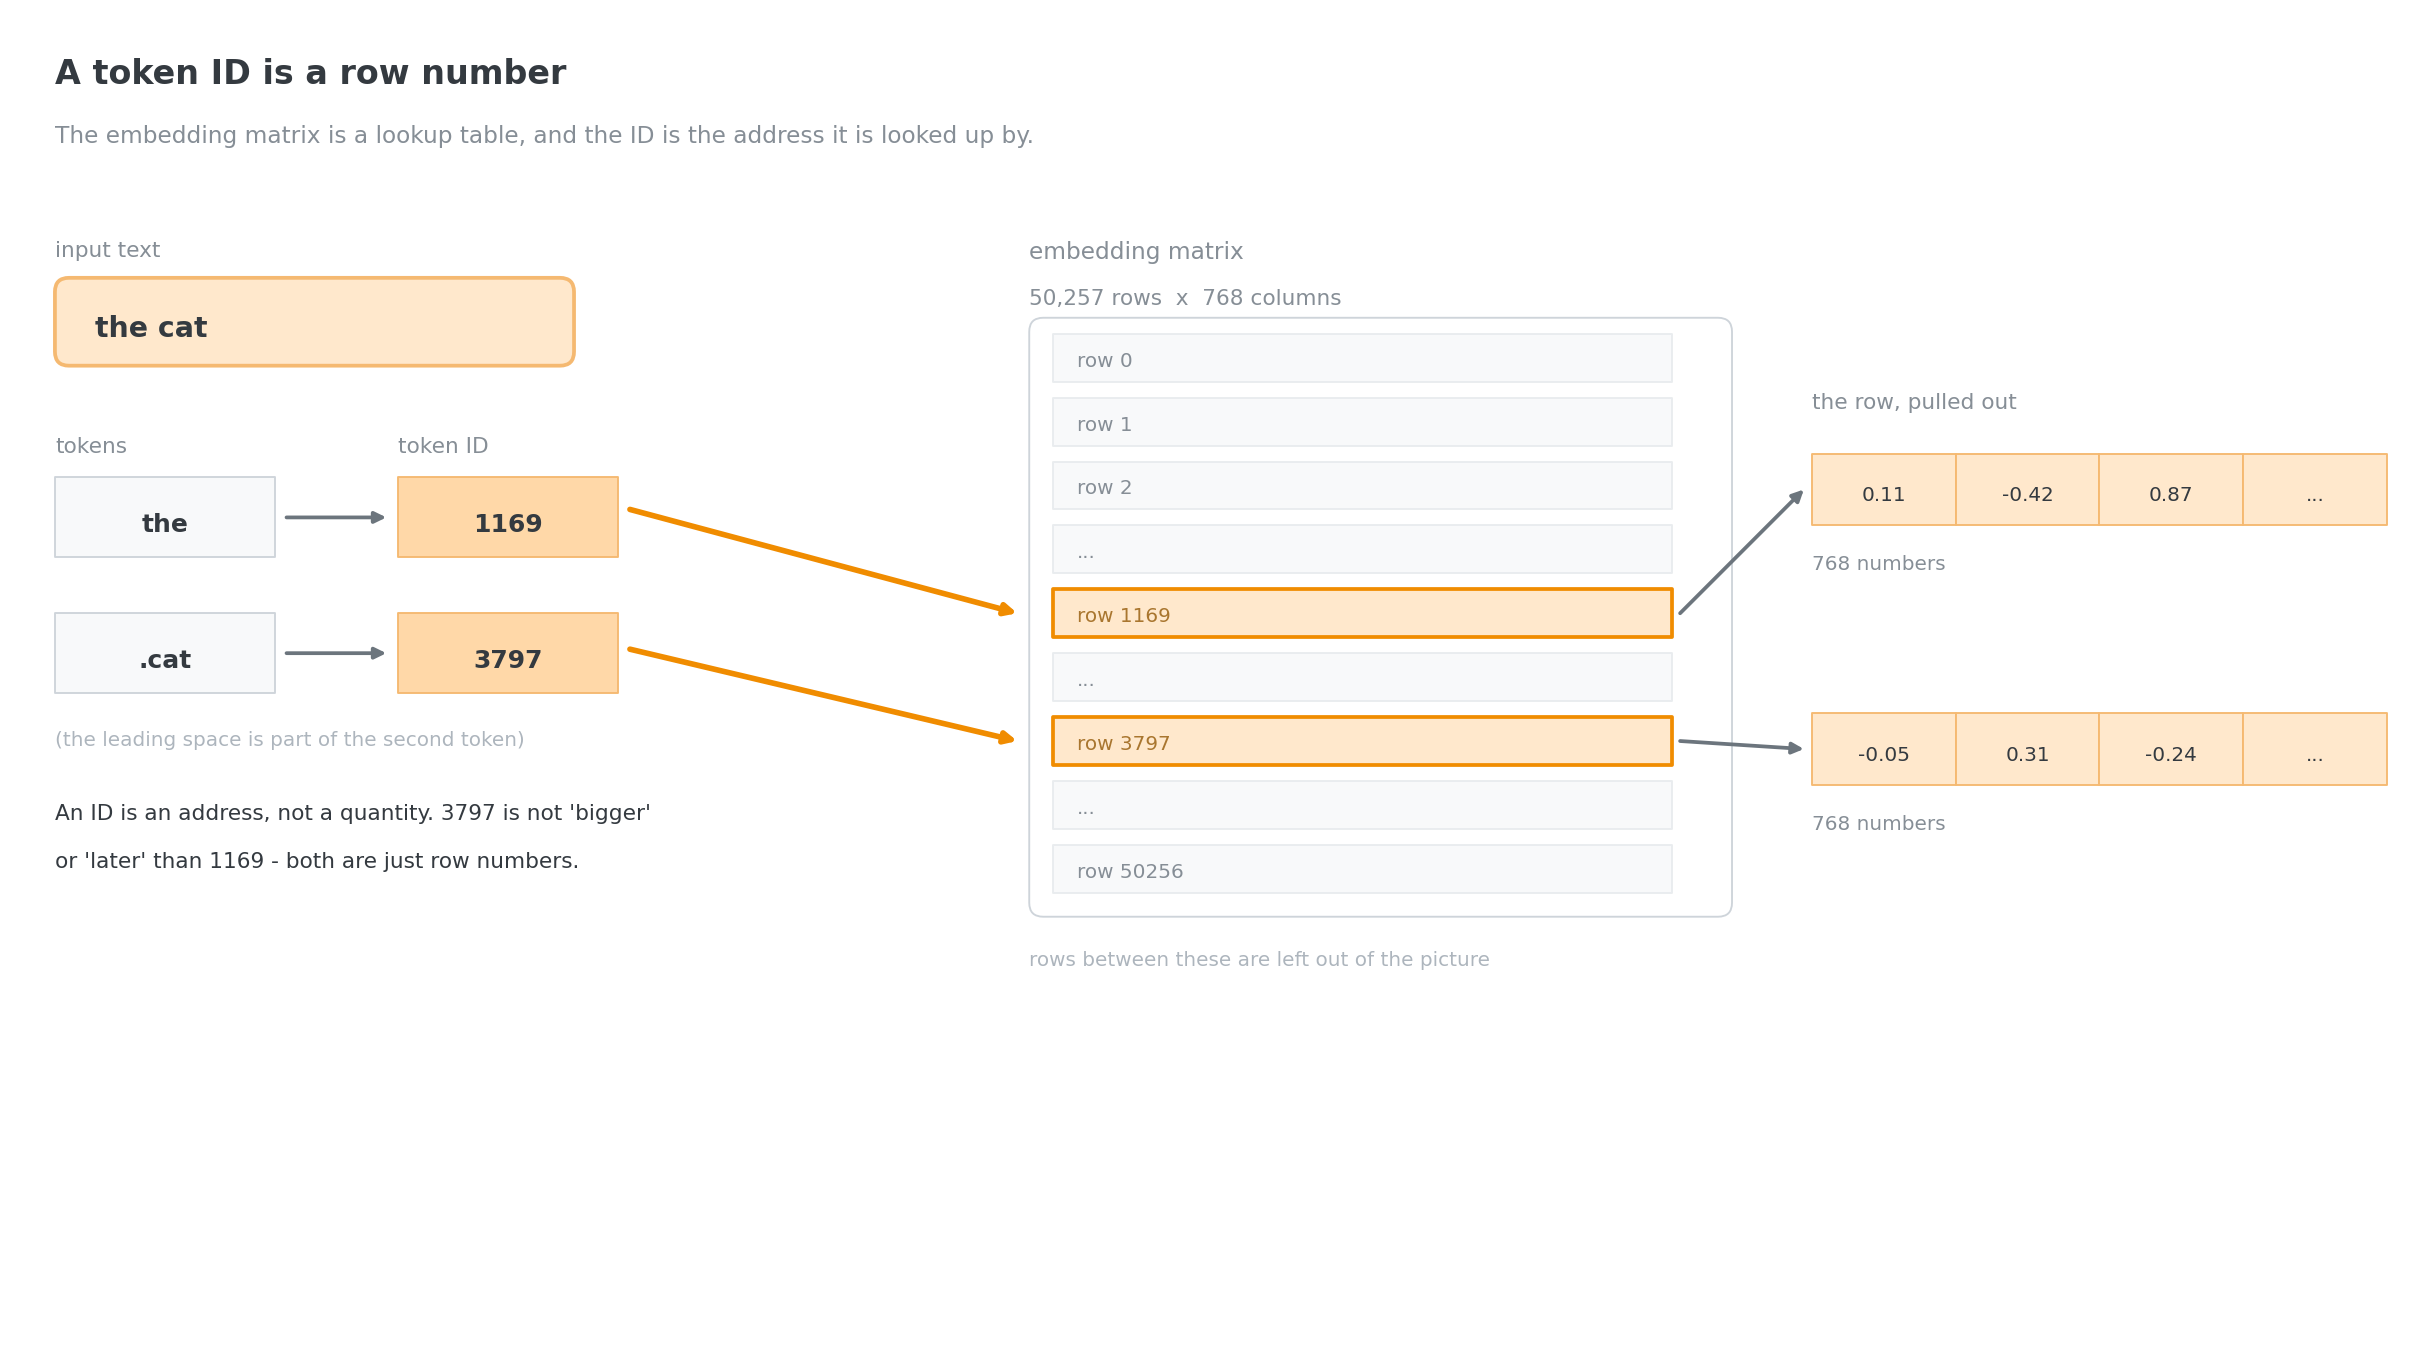

The picture is the one from Module 2. The matrix drawn there is GPT-2's, 50,257 rows by 768
columns. This lab uses `bert-base-cased`, which has 28,996 rows and the same 768 columns.

This lab downloads model weights, about 400 megabytes for `bert-base-cased`. No GPU is needed, but
switch on the T4 if it is available: **Runtime > Change runtime type > T4 GPU**.



In [ ]:
!pip install -q transformers

---

## Part 1 · The matrix the model is holding

A model does not store text and it does not store meaning. It stores one vector for every token in
its tokenizer's vocabulary, in one matrix, and the token id is the row number.

That matrix has a size you can print, and the two numbers in it are the two you already know:
vocabulary size from Module 2, and the model's hidden size.

- **Python note:** `AutoModel` loads a model without any task specific head on top, so what comes
  out is the representation itself rather than a prediction.

> **Predict before running.**
>
> `bert-base-cased` has a vocabulary of 28,996 tokens and a hidden size of 768.
>
> 1. How many rows will its embedding matrix have, and how many columns?
> 2. How many numbers is that in total?

**Your prediction:**

_Type here._

> Model card: [bert-base-cased](https://huggingface.co/google-bert/bert-base-cased). Read it for the
> vocabulary size, the casing, and what the model was trained on, since all three decide what the
> matrix below holds.

In [ ]:
# quiet the loading report and the progress bar warning, neither is an error
import warnings
warnings.filterwarnings("ignore")

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
model = AutoModel.from_pretrained("bert-base-cased")

embedding_matrix = model.get_input_embeddings().weight

print("embedding matrix shape:", tuple(embedding_matrix.shape))
print("vocabulary size       :", tokenizer.vocab_size)
print("hidden size           :", model.config.hidden_size)
print("total numbers         :", embedding_matrix.numel())

**Interpret the output.**

1. Record the shape. Which of the two numbers came from the tokenizer?
2. This matrix is part of the file you just downloaded. What would happen to it if you swapped in a
   tokenizer with a different vocabulary?
3. Nothing has been fed to the model yet, and these numbers already exist. When were they decided?

---

## Part 2 · One id, one row

The lookup is nothing more than indexing. Take the id of a token and read that row.

- **Python note:** `matrix[i]` returns row `i`. `.shape` on that row gives its length, which is the
  hidden size.

> **Predict before running.**
>
> The word `world` has one id in this vocabulary.
>
> 1. How many numbers will its row contain?
> 2. Would the same id give the same row on a second run of this cell?

**Your prediction:**

_Type here._

In [ ]:
word_id = tokenizer.convert_tokens_to_ids("world")

row = embedding_matrix[word_id]

print("token 'world' has id", word_id)
print("its row has", row.shape[0], "numbers")
print("the first eight of them:", row[:8].tolist())

**Interpret the output.**

1. Record the id and the first few numbers. Are they readable on their own?
2. This is what we call the static embedding. Say in one sentence what makes it static.
3. The word `world` appears in millions of sentences. How many rows does the model hold for it?

Part 4 turns on the word `bank`. Read its row here, twice, so the claim made there rests on
something you have already seen.

In [ ]:
bank_id = tokenizer.convert_tokens_to_ids("bank")

first_lookup = embedding_matrix[bank_id]
second_lookup = embedding_matrix[bank_id]

print("token 'bank' has id", bank_id)
print("first lookup, first four numbers :", first_lookup[:4].tolist())
print("second lookup, first four numbers:", second_lookup[:4].tolist())
print("largest difference between them  :", float((first_lookup - second_lookup).abs().max()))

One row for `bank`, the same numbers every time, and nothing about any sentence reaches it.

---

## Part 3 · A batch of ids into the model

Now feed the model. The input is exactly what the tokenizer handed you in the Module 2 lab: ids and
an attention mask, padded to a rectangle.

- **Python note:** `import torch` brings in PyTorch, the library this model is built on. Every input
  and every output below is a torch tensor, a numeric array that carries a shape, which is why the
  shapes are the thing worth printing.
- **Python note:** the tokenizer returns a dictionary holding `input_ids` and `attention_mask`.
  `model(**inputs)` unpacks that dictionary into named arguments, so both reach the model without
  being typed out one at a time.
- **Python note:** `torch.no_grad()` switches off gradient tracking. Gradients are only needed when
  a model is being trained, and holding them costs memory, so running a model for its output alone
  goes inside that block.

> **Predict before running.**
>
> Three sentences of different lengths, padded, go in together.
>
> 1. The output has three numbers in its shape. What do you expect them to be?
> 2. Where does each of the three come from?

**Your prediction:**

_Type here._

In [ ]:
import torch

sentences = [
    "The river bank was muddy.",
    "She went to the bank to deposit a check.",
    "Short.",
]

inputs = tokenizer(sentences, padding=True, return_tensors="pt")

print("input_ids shape:", tuple(inputs["input_ids"].shape))
print()

with torch.no_grad():
    output = model(**inputs)

print("output shape   :", tuple(output.last_hidden_state.shape))

**Interpret the output.**

1. Record both shapes. Which numbers are the same in each, and which is different?
2. The third number changed between input and output. What was it before and what is it now?
3. One vector came out for every token position, padding included. What is in the vectors sitting at
   the padded positions, and why does the attention mask matter?

---

## Part 4 · Contextual embeddings

Parts 1 and 2 were the static embedding, one row per token, read straight out of the matrix. This
part is the other kind, the contextual embedding, which the model computes for a token from the
sentence it sits in.

Both of the first two sentences contain the word `bank`, and they mean two different things. The
static row from Part 2 cannot tell them apart because there is only one row.

The output of Part 3 can. This is the whole difference between a lookup and a computation.

- **Python note:** `.index(value)` finds the position of a value in a list. We need the position of
  the `bank` token inside each sentence, because that is which row of the output to read.

Start with what goes in. Find the `bank` position in each sentence, read the row the model starts
from at that position, and compare the two.

In [ ]:
input_vectors = []
for row in range(2):
    ids = inputs["input_ids"][row].tolist()
    position = ids.index(bank_id)
    input_vectors.append(embedding_matrix[ids[position]])
    print("sentence", row, ": 'bank' sits at position", position, "with id", ids[position])

print()
print("are the two input rows identical?", torch.equal(input_vectors[0], input_vectors[1]))

going_in = torch.nn.functional.cosine_similarity(input_vectors[0], input_vectors[1], dim=0)
print("cosine similarity going in:", round(going_in.item(), 4))

Identical, and a cosine of exactly 1.0. Both sentences hand the model the same row.

Now the contextual embedding. Read the model's output at the same position in each sentence and
compare those two.

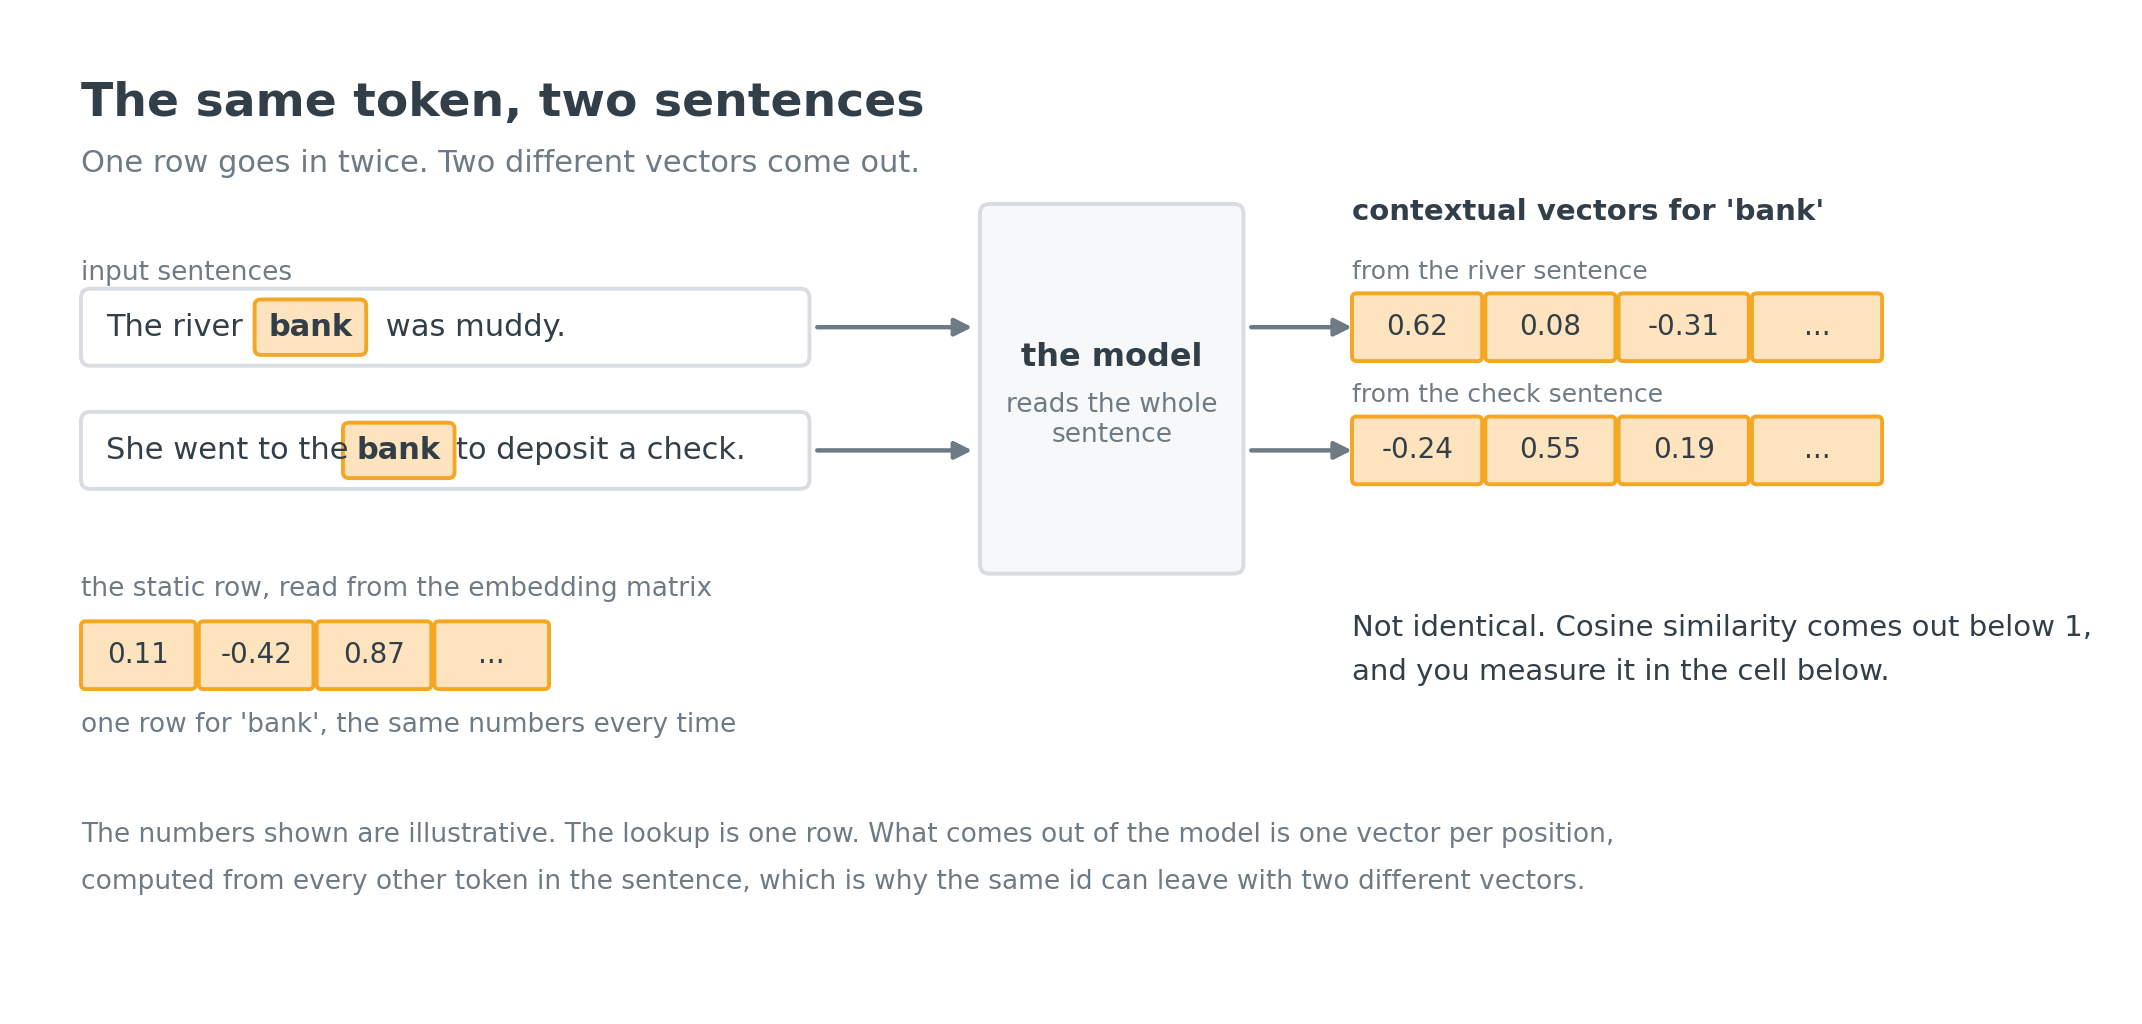

> **Predict before running.**
>
> The vector for `bank` is read out of the model's output for each of the two sentences, then
> compared with cosine similarity.
>
> 1. Will the two vectors be identical?
> 2. Cosine similarity runs from -1 to 1. What value would you expect, and what value would prove
>    the model was doing nothing but a lookup?


**Your prediction:**

_Type here._

In [ ]:
vectors = []
for row in range(2):
    ids = inputs["input_ids"][row].tolist()
    position = ids.index(bank_id)
    vectors.append(output.last_hidden_state[row][position])
    print("sentence", row, ": reading the model output at position", position)

print()
print("are the two vectors identical?", torch.equal(vectors[0], vectors[1]))

similarity = torch.nn.functional.cosine_similarity(vectors[0], vectors[1], dim=0)
print("cosine similarity between them:", round(similarity.item(), 4))

**Interpret the output.**

1. Record the similarity. Is it 1.0?
2. Both sentences used the same token with the same id, so both started from the same row of the
   matrix in Part 2. Explain, in one sentence, what happened between the lookup and the output.
3. If the similarity had come out as exactly 1.0, what would that have told you about the model?
4. `river bank` and `bank to deposit a check` are two meanings of one word. Was the similarity closer
   to 1 or to 0, and does that match what you expected?

Look at the three vectors side by side. Each strip is one vector, and each square is one of its
numbers, colored by value.

In [ ]:
import matplotlib.pyplot as plt

static_row = embedding_matrix[bank_id].detach()

strips = []
strips.append(static_row[:40].tolist())
strips.append(vectors[0][:40].tolist())
strips.append(vectors[1][:40].tolist())

names = ["static row", "in 'river bank'", "in 'bank to deposit'"]

figure, axis = plt.subplots(figsize=(11, 2.6))
picture = axis.imshow(strips, aspect="auto", cmap="coolwarm")
axis.set_yticks([0, 1, 2])
axis.set_yticklabels(names)
axis.set_xlabel("the first 40 of the 768 numbers")
axis.set_title("One token, three vectors")
figure.colorbar(picture)
plt.show()

**Interpret the picture.**

1. The bottom two strips came from the same row of the matrix. Where along them do you see the
   largest disagreement?
2. The top strip is the lookup and it never changes. The other two changed because of the words
   around them. Which of the two looks further from the top strip?
3. Only 40 of the 768 numbers are drawn. What would you check before trusting a pattern you see in
   this picture?

The three vectors do not share a scale, so read the picture for where the values differ, not for how
strong the colors are.

> **Your turn.**
>
> Compare the contextual vector against the static row it started from:
>
> ```python
> static = embedding_matrix[bank_id]
> print(torch.nn.functional.cosine_similarity(static, vectors[0], dim=0))
> ```
>
> Is the contextual vector closer to the static row it came from, or to the other sentence's
> contextual vector?

In [ ]:
# Your turn: compare a contextual vector with the static row.

---

## Part 5 · One vector for a whole sentence

Part 3 gave one vector per token. A search index, a clustering job and a classifier all need one
vector per document instead.

The simplest way to get one is to average the token vectors, and the mask decides which ones count.

- **Python note:** `inputs["attention_mask"]` is the row of 1s and 0s the tokenizer produced next to
  the ids. A 1 marks a real token, a 0 marks padding. It is the only record of which positions were
  invented to square off the rectangle, so an average taken without it would fold padding into the
  answer.
- **Python note:** `torch.clamp(..., min=1e-9)` stops a division by zero if a row somehow had no
  real tokens at all.

> **Predict before running.**
>
> 1. If you average all the token vectors including the padded positions, what goes wrong?
> 2. What should the shape of the result be for three sentences?

**Your prediction:**

_Type here._

In [ ]:
mask = inputs["attention_mask"]

# expand the mask so it lines up with every number in every token vector
expanded = mask.unsqueeze(-1).expand(output.last_hidden_state.shape).float()

# zero out the padded positions, sum, then divide by how many real tokens there were
summed = torch.sum(output.last_hidden_state * expanded, dim=1)
counts = torch.clamp(expanded.sum(dim=1), min=1e-9)
sentence_vectors = summed / counts

print("per token shape   :", tuple(output.last_hidden_state.shape))
print("per sentence shape:", tuple(sentence_vectors.shape))
print()

for row in range(len(sentences)):
    for other in range(row + 1, len(sentences)):
        score = torch.nn.functional.cosine_similarity(
            sentence_vectors[row], sentence_vectors[other], dim=0)
        print(round(score.item(), 4), " ", sentences[row], "  ||  ", sentences[other])

**Interpret the output.**

1. Record the two shapes. Which dimension disappeared, and what did averaging do to it?
2. Record the three similarity scores. Which pair scored highest?
3. Sentences 1 and 2 share the word `bank` and share almost nothing else in meaning. Did their
   scores reflect that?
4. Mean pooling treats every token as equally important. Name one sentence where that would give a
   misleading vector.

Averaging is the crude version. Models trained specifically to produce sentence vectors do better,
and those are what the semantic search module uses.

---

## Part 6 · Four constraints this creates

1. **The embedding matrix is a real fraction of the model.** 28,996 rows by 768 columns is over 22
   million numbers before a single layer of the network. Doubling the vocabulary doubles it.
2. **The tokenizer cannot be changed.** Every row was learned against the ids that tokenizer
   produces. New ids point at rows trained on other pieces of text.
3. **Contextual vectors cannot be cached by word.** A static embedding is a lookup you can store
   once. A contextual one depends on the whole sentence, so it must be computed per input.
4. **Padding costs vectors you throw away.** Every padded position produced a full vector that the
   mask then discards.

---

## Check yourself

Answer in a sentence each, from your own output above.

1. Give the shape of the embedding matrix and say where each of its two numbers came from.
2. A model receives the id 1234 twice, in two different sentences. How many rows of the embedding
   matrix are read, and how many vectors come out?
3. Explain in one sentence why a pretrained model cannot be given a different tokenizer.
4. You need one vector per document for a search index. What do you do with the per token output,
   and what role does the attention mask play?
5. Which is the static embedding and which is the contextual one: the row from Part 2, or the vector
   from Part 3?

---

## Summary

- A model holds one vector per token in its tokenizer's vocabulary, in a matrix indexed by token id.
- Reading that matrix is a lookup, and the result is the same every time. That is a static embedding.
- Running the model turns those rows into one vector per token position, computed from the whole
  sequence. That is a contextual embedding, and it is why the same word can carry two meanings.
- Averaging the token vectors with the attention mask gives one vector for a whole sentence, which
  is what search, clustering and classification consume.
- The embedding matrix is why the tokenizer is frozen. Its rows were learned against those ids.

**Next:** where the numbers in a static embedding come from in the first place, and what Word2Vec
was actually optimising when it learned them.

---

## References

**Course.** [Models](https://huggingface.co/learn/llm-course/chapter2/3) ·
[Tokenizers](https://huggingface.co/learn/llm-course/chapter2/4) ·
[Putting it all together](https://huggingface.co/learn/llm-course/chapter2/6)

**Documentation.** [AutoModel](https://huggingface.co/docs/transformers/model_doc/auto) ·
[Tokenizers](https://huggingface.co/docs/transformers/fast_tokenizers)

**Reading.** Alammar and Grootendorst, *Hands-On Large Language Models*, chapter 2, the sections on
token embeddings, contextualized word embeddings and text embeddings.

**Models.** [bert-base-cased](https://huggingface.co/google-bert/bert-base-cased)